
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
АНАЛИЗ ДЛЯ ВСЕХ МАГАЗИНОВ
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

⏰ АНАЛИЗ ВРЕМЕНИ ЗАКАЗОВ - Все магазины
📊 Всего чеков: 86
📊 Всего товаров: 2517
📊 Общая выручка: 20113.48 BYN

📊 Пиковый час по количеству заказов: 19:00 - 20:00
💰 Пиковый час по выручке: 19:00 - 20:00
📦 Пиковый час по количеству товаров: 19:00 - 20:00


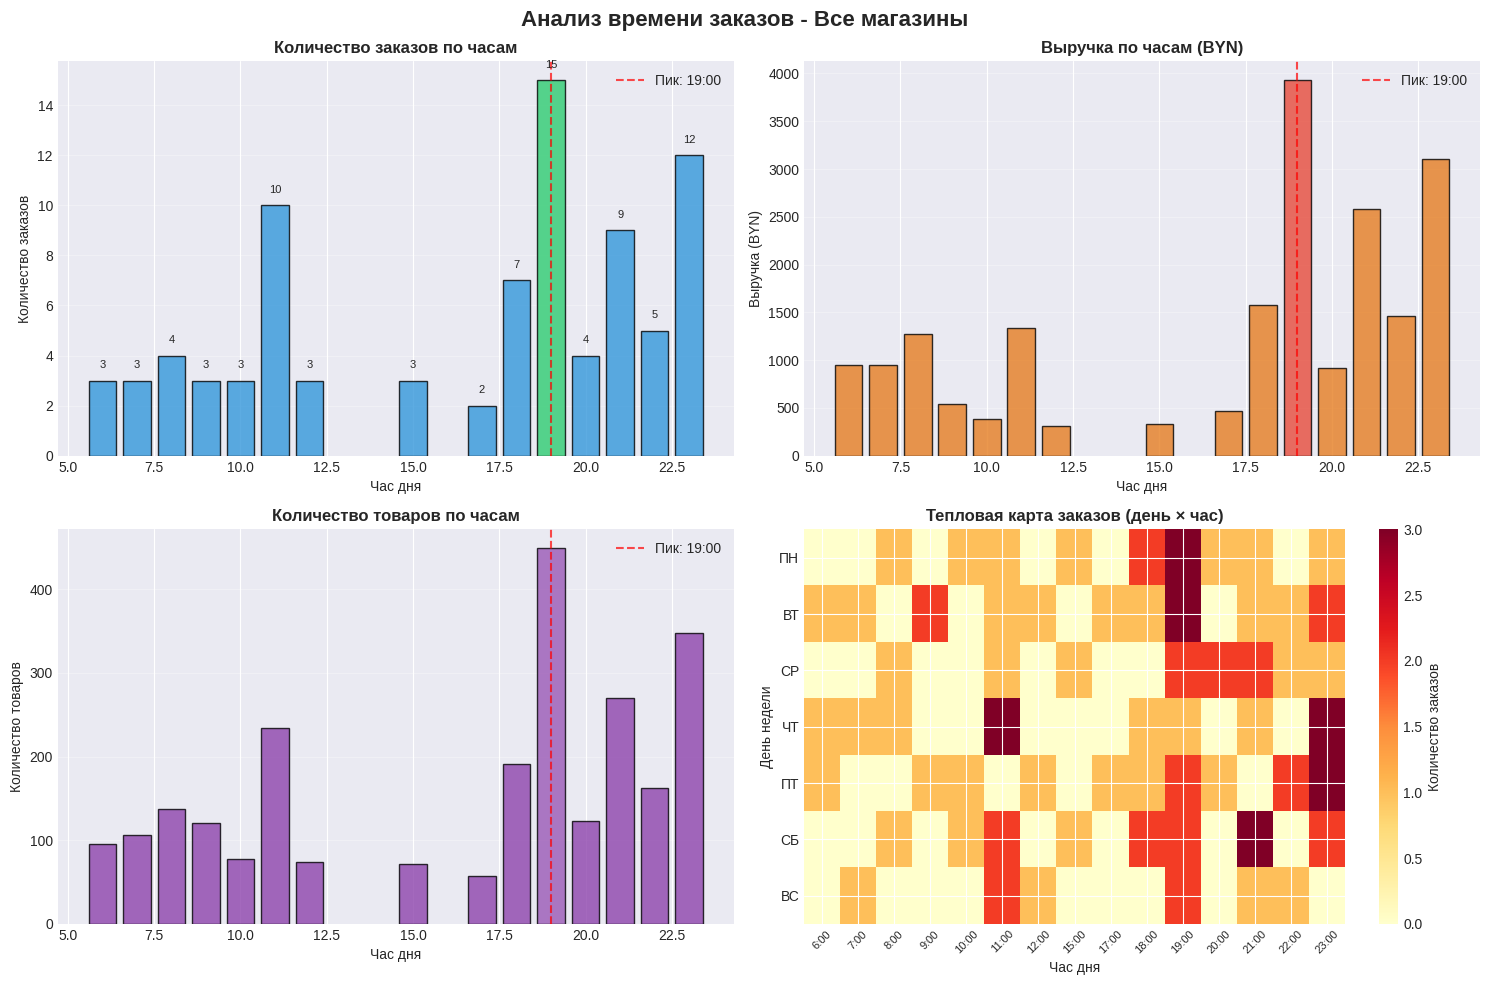


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
АНАЛИЗ ДЛЯ МАГАЗИНА EDOstavka
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

⏰ АНАЛИЗ ВРЕМЕНИ ЗАКАЗОВ - edostavka
📊 Всего чеков: 58
📊 Всего товаров: 1790
📊 Общая выручка: 16230.96 BYN

📊 Пиковый час по количеству заказов: 19:00 - 20:00
💰 Пиковый час по выручке: 19:00 - 20:00
📦 Пиковый час по количеству товаров: 19:00 - 20:00


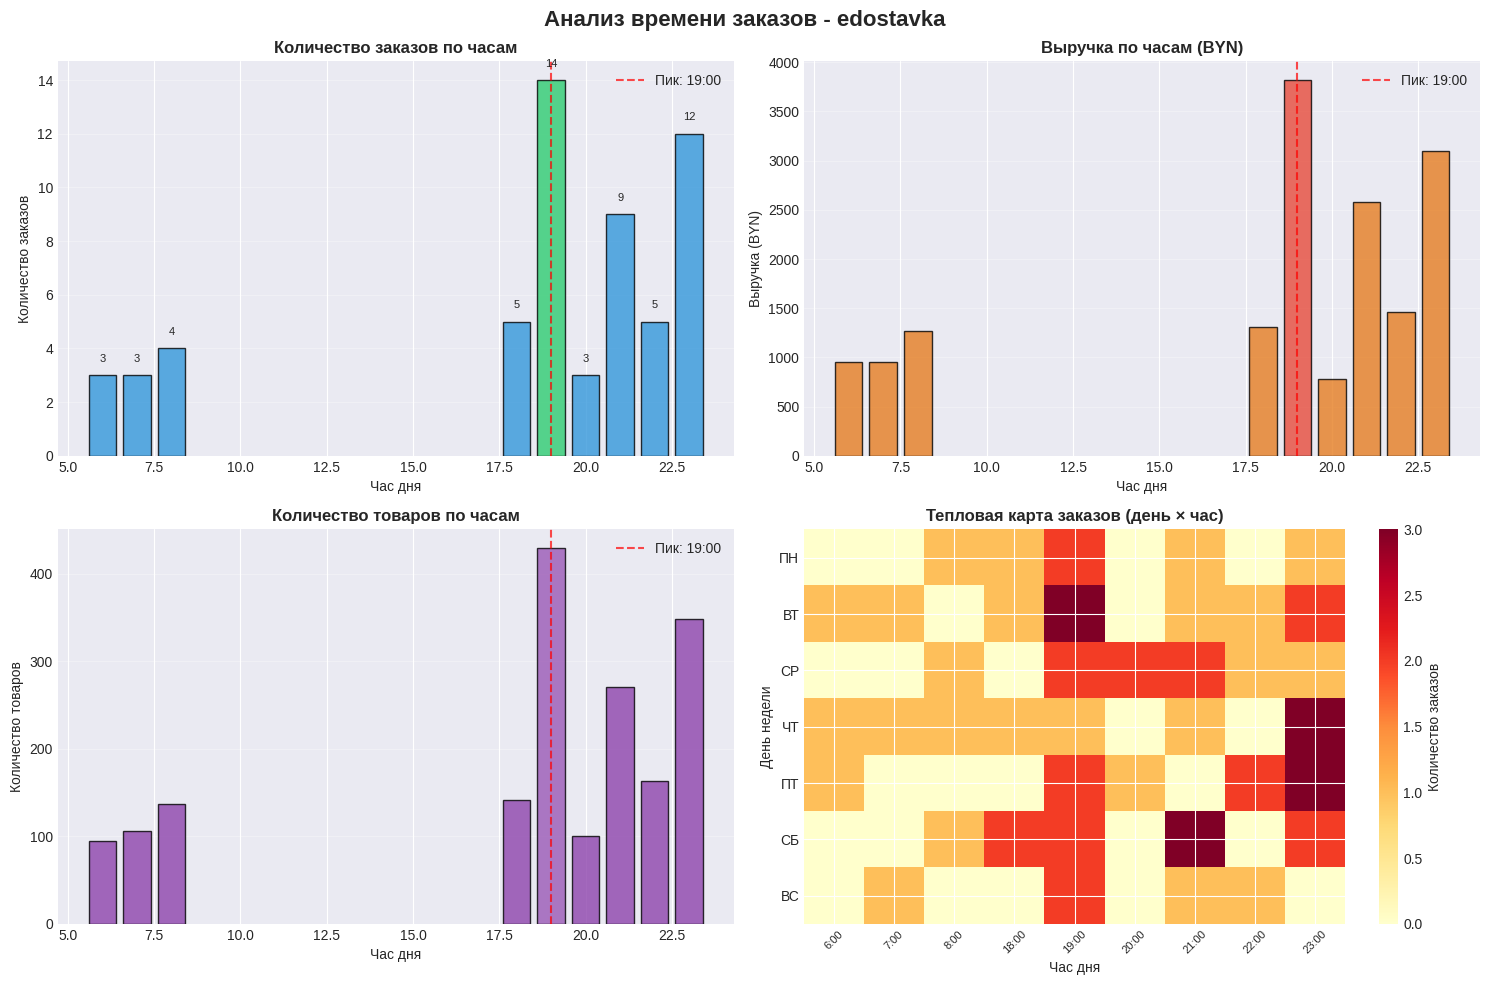


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
АНАЛИЗ ДЛЯ МАГАЗИНА СОСЕДИ
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

⏰ АНАЛИЗ ВРЕМЕНИ ЗАКАЗОВ - sosedi
📊 Всего чеков: 28
📊 Всего товаров: 727
📊 Общая выручка: 3882.52 BYN

📊 Пиковый час по количеству заказов: 11:00 - 12:00
💰 Пиковый час по выручке: 11:00 - 12:00
📦 Пиковый час по количеству товаров: 11:00 - 12:00


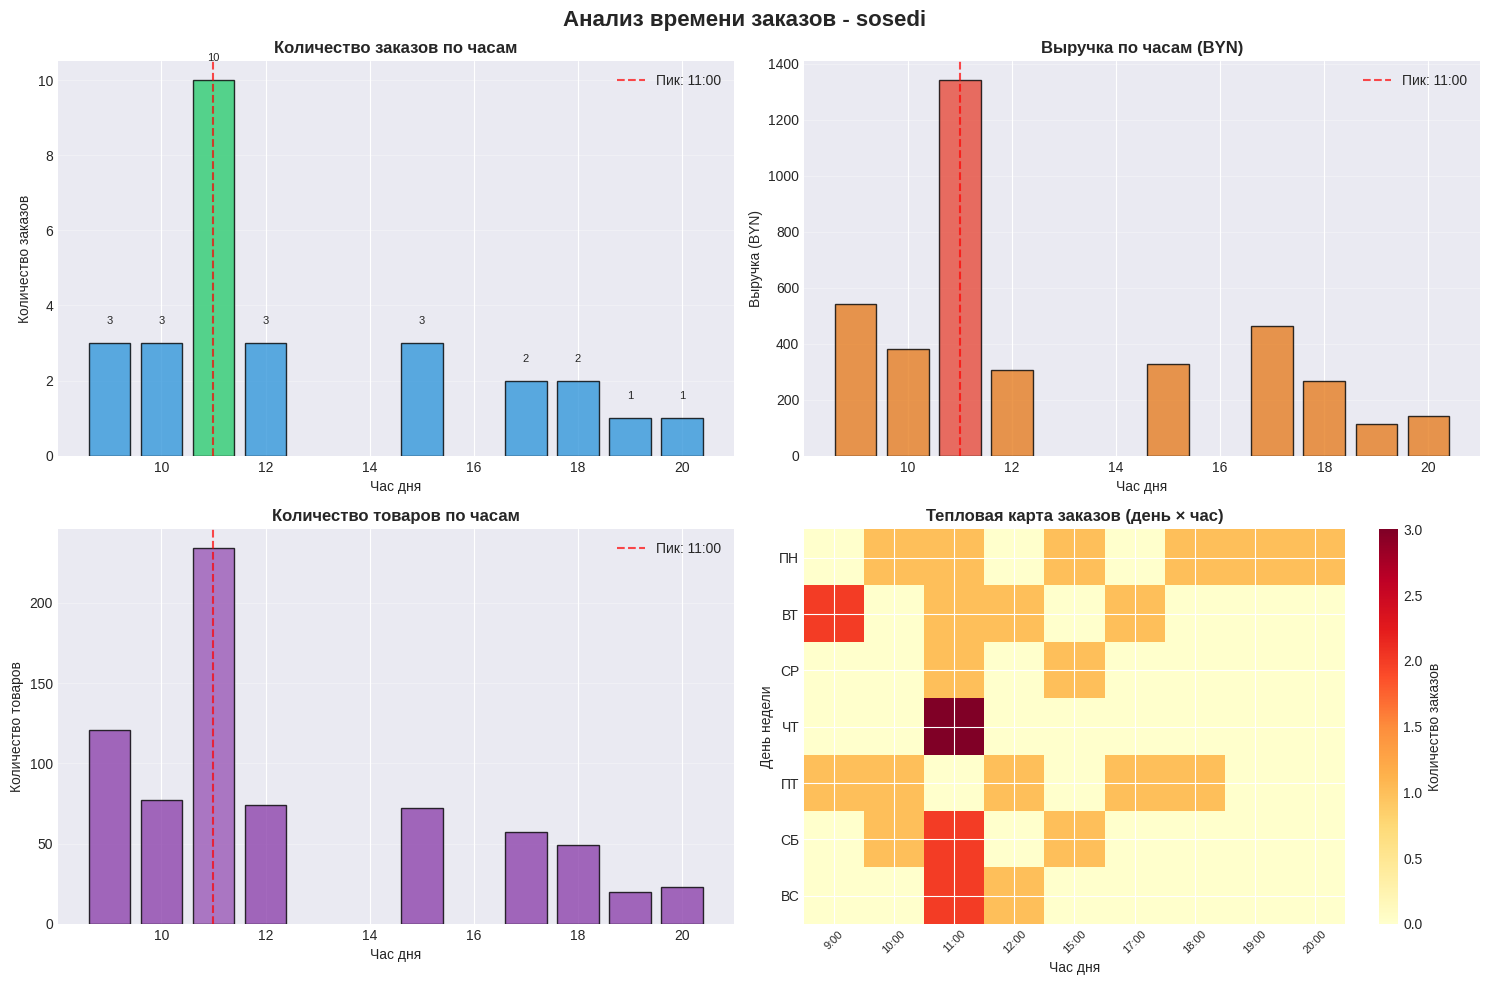


🏪 СРАВНИТЕЛЬНЫЙ АНАЛИЗ МАГАЗИНОВ

💰 Средний чек:
   edostavka: 279.84 BYN
   соседи: 138.66 BYN

⏰ Пиковый час заказов:
   edostavka: 19:00-20:00
   соседи: 11:00-12:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

def analyze_order_time(df, shop_filter=None):
    """
    Анализ времени заказов
    
    Параметры:
    df - DataFrame с данными
    shop_filter - название магазина ('edostavka', 'sosedi') или None для всех
    """
    
    if shop_filter:
        df = df[df['Магазин'] == shop_filter].copy()
        shop_name = shop_filter
    else:
        shop_name = "Все магазины"
    
    # Преобразуем дату
    df['Дата заказа'] = pd.to_datetime(df['Дата заказа'])
    
    # Создаем копию для временного анализа
    df_time = df.copy()
    df_time['Час'] = df_time['Дата заказа'].dt.hour
    df_time['Минута'] = df_time['Дата заказа'].dt.minute
    df_time['Время'] = df_time['Дата заказа'].dt.strftime('%H:%M')
    
    # Агрегируем по чеку (один чек = один файл)
    cheque_aggregated = df_time.groupby('Файл').agg({
        'Час': 'first',
        'Дата заказа': 'first',
        'Итого (BYN)': 'sum',
        'Магазин': 'first'
    }).reset_index()
    
    # Группируем по часам для заказов
    hourly_orders = cheque_aggregated.groupby('Час')['Файл'].count()
    
    # Группируем по часам для товаров
    hourly_items = df_time.groupby('Час')['Товар'].count()
    
    # Находим пиковые часы
    peak_hour_orders = hourly_orders.idxmax() if not hourly_orders.empty else 0
    peak_hour_items = hourly_items.idxmax() if not hourly_items.empty else 0
    
    # Выручка по часам (сумма всех товаров в этот час)
    hourly_revenue = df_time.groupby('Час')['Итого (BYN)'].sum()
    peak_hour_revenue = hourly_revenue.idxmax() if not hourly_revenue.empty else 0
    
    print("="*60)
    print(f"⏰ АНАЛИЗ ВРЕМЕНИ ЗАКАЗОВ - {shop_name}")
    print("="*60)
    print(f"📊 Всего чеков: {len(cheque_aggregated)}")
    print(f"📊 Всего товаров: {len(df_time)}")
    print(f"📊 Общая выручка: {df_time['Итого (BYN)'].sum():.2f} BYN")
    print(f"\n📊 Пиковый час по количеству заказов: {peak_hour_orders}:00 - {peak_hour_orders+1}:00")
    print(f"💰 Пиковый час по выручке: {peak_hour_revenue}:00 - {peak_hour_revenue+1}:00")
    print(f"📦 Пиковый час по количеству товаров: {peak_hour_items}:00 - {peak_hour_items+1}:00")
    
    # ========== ГРАФИКИ ==========
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Анализ времени заказов - {shop_name}', fontsize=16, fontweight='bold')
    
    # 1. График количества заказов по часам
    colors_orders = ['#2ecc71' if i == peak_hour_orders else '#3498db' for i in hourly_orders.index]
    axes[0,0].bar(hourly_orders.index, hourly_orders.values, color=colors_orders, 
                 edgecolor='black', alpha=0.8, width=0.8)
    axes[0,0].axvline(peak_hour_orders, color='red', linestyle='--', alpha=0.7, 
                     label=f'Пик: {peak_hour_orders}:00')
    axes[0,0].set_title('Количество заказов по часам', fontsize=12, fontweight='bold')
    axes[0,0].set_xlabel('Час дня', fontsize=10)
    axes[0,0].set_ylabel('Количество заказов', fontsize=10)
    axes[0,0].legend()
    axes[0,0].grid(axis='y', alpha=0.3)
    
    # Добавляем значения на столбцы
    for i, (hour, count) in enumerate(hourly_orders.items()):
        axes[0,0].text(hour, count + 0.5, str(int(count)), ha='center', fontsize=8)
    
    # 2. График выручки по часам
    colors_revenue = ['#e74c3c' if i == peak_hour_revenue else '#e67e22' for i in hourly_revenue.index]
    axes[0,1].bar(hourly_revenue.index, hourly_revenue.values, color=colors_revenue,
                 edgecolor='black', alpha=0.8, width=0.8)
    axes[0,1].axvline(peak_hour_revenue, color='red', linestyle='--', alpha=0.7,
                     label=f'Пик: {peak_hour_revenue}:00')
    axes[0,1].set_title('Выручка по часам (BYN)', fontsize=12, fontweight='bold')
    axes[0,1].set_xlabel('Час дня', fontsize=10)
    axes[0,1].set_ylabel('Выручка (BYN)', fontsize=10)
    axes[0,1].legend()
    axes[0,1].grid(axis='y', alpha=0.3)
    
    # 3. Количество товаров по часам
    colors_items = ['#9b59b6' if i == peak_hour_items else '#8e44ad' for i in hourly_items.index]
    axes[1,0].bar(hourly_items.index, hourly_items.values, color=colors_items,
                 edgecolor='black', alpha=0.8, width=0.8)
    axes[1,0].axvline(peak_hour_items, color='red', linestyle='--', alpha=0.7,
                     label=f'Пик: {peak_hour_items}:00')
    axes[1,0].set_title('Количество товаров по часам', fontsize=12, fontweight='bold')
    axes[1,0].set_xlabel('Час дня', fontsize=10)
    axes[1,0].set_ylabel('Количество товаров', fontsize=10)
    # axes[1,0].set_xticks(range(0, 24))
    axes[1,0].legend()
    axes[1,0].grid(axis='y', alpha=0.3)
    
    # 4. Тепловая карта (день недели + час)
    df_time['День недели'] = df_time['Дата заказа'].dt.day_name()
    weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    weekday_names = {'Monday': 'ПН', 'Tuesday': 'ВТ', 'Wednesday': 'СР', 
                    'Thursday': 'ЧТ', 'Friday': 'ПТ', 'Saturday': 'СБ', 'Sunday': 'ВС'}
    
    # Создаем сводную таблицу для заказов
    heatmap_data = cheque_aggregated.groupby([cheque_aggregated['Дата заказа'].dt.dayofweek, 'Час'])['Файл'].count().unstack(fill_value=0)
    heatmap_data.index = [weekday_names[weekday_order[i]] for i in heatmap_data.index]
    
    im = axes[1,1].imshow(heatmap_data.values, cmap='YlOrRd', aspect='auto', interpolation='nearest')
    axes[1,1].set_xticks(range(len(heatmap_data.columns)))
    axes[1,1].set_xticklabels([f"{h}:00" for h in heatmap_data.columns], rotation=45, fontsize=8)
    axes[1,1].set_yticks(range(len(heatmap_data.index)))
    axes[1,1].set_yticklabels(heatmap_data.index, fontsize=10)
    axes[1,1].set_title('Тепловая карта заказов (день × час)', fontsize=12, fontweight='bold')
    axes[1,1].set_xlabel('Час дня', fontsize=10)
    axes[1,1].set_ylabel('День недели', fontsize=10)
    
    plt.colorbar(im, ax=axes[1,1], label='Количество заказов')
    plt.tight_layout()
    plt.show()
    
    return hourly_orders, hourly_revenue, hourly_items, cheque_aggregated

# df = pd.read_csv('all_checks_big.csv', encoding='utf-8-sig')
df = pd.read_csv('./data/processed/processed_file.csv', encoding='utf-8-sig')

# Преобразуем дату
df['Дата заказа'] = pd.to_datetime(df['Дата заказа'])

print("\n" + "!"*30)
print("АНАЛИЗ ДЛЯ ВСЕХ МАГАЗИНОВ")
print("!"*30 + "\n")
hourly_orders_all, hourly_revenue_all, hourly_items_all, cheque_agg_all = analyze_order_time(df)


print("\n" + "!"*30)
print("АНАЛИЗ ДЛЯ МАГАЗИНА Edostavka")
print("!"*30 + "\n")
hourly_orders_edo, hourly_revenue_edo, hourly_items_edo, cheque_agg_edo = analyze_order_time(df, 'edostavka')

print("\n" + "!"*30)
print("АНАЛИЗ ДЛЯ МАГАЗИНА СОСЕДИ")
print("!"*30 + "\n")
hourly_orders_sos, hourly_revenue_sos, hourly_items_sos, cheque_agg_sos = analyze_order_time(df, 'sosedi')

# ========== СРАВНИТЕЛЬНЫЙ АНАЛИЗ МАГАЗИНОВ ==========

print("\n" + "="*60)
print("🏪 СРАВНИТЕЛЬНЫЙ АНАЛИЗ МАГАЗИНОВ")
print("="*60)

# Сравнение средних чеков
avg_cheque_edo = cheque_agg_edo['Итого (BYN)'].mean() if not cheque_agg_edo.empty else 0
avg_cheque_sos = cheque_agg_sos['Итого (BYN)'].mean() if not cheque_agg_sos.empty else 0

print(f"\n💰 Средний чек:")
print(f"   edostavka: {avg_cheque_edo:.2f} BYN")
print(f"   соседи: {avg_cheque_sos:.2f} BYN")

# Сравнение пиковых часов
peak_edo = cheque_agg_edo.groupby('Час')['Файл'].count().idxmax() if not cheque_agg_edo.empty else 0
peak_sos = cheque_agg_sos.groupby('Час')['Файл'].count().idxmax() if not cheque_agg_sos.empty else 0

print(f"\n⏰ Пиковый час заказов:")
print(f"   edostavka: {peak_edo}:00-{peak_edo+1}:00")
print(f"   соседи: {peak_sos}:00-{peak_sos+1}:00")